# Temperature Downscaling — Data Exploration

**Goal:** Downscale MODIS 1km Land Surface Temperature (LST) to ~5km (coarsened), then use high-resolution predictors (Sentinel-2, LULC, DEM) to reconstruct/downscale back. The original 1km data serves as ground truth for evaluation.

**Study area:** Colorado Front Range, 2022–2023

**Datasets:**
| Source | Native Resolution | Temporal | Role |
|--------|------------------|----------|------|
| MODIS MOD11A1 | 1km | Daily | LST target (coarsen → downscale → evaluate) |
| Sentinel-2 | 10m | ~2/month | NDVI, NDWI predictors |
| NLCD LULC | 30m | Annual (static) | Land cover predictor |
| ASTER GDEM | 30m | Static | Elevation predictor |

## 0. Setup

In [1]:
!pip install -q rasterio geopandas pyhdf rioxarray xarray matplotlib huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.3/780.3 kB 72.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.8 MB/s eta 0:00:00


In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd
from pyhdf.SD import SD, SDC
from shapely.geometry import box
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Download Data from Hugging Face

Download the dataset from [`akhot2/downscaling`](https://huggingface.co/datasets/akhot2/downscaling) on Hugging Face.

**Note:** The full dataset is ~37 GB. For exploration we download only a subset of MODIS and Sentinel-2 files (January 2022, one tile each). ASTER, LULC, and bounding box are small and downloaded in full. Remove the `allow_patterns` / `ignore_patterns` to get everything.

In [3]:
from huggingface_hub import snapshot_download

DATA_ROOT = 'data'

# Download small/static folders in full, skip MODIS and Sentinel-2
snapshot_download(
    repo_id='akhot2/downscaling',
    repo_type='dataset',
    local_dir=DATA_ROOT,
    ignore_patterns=['MODIS/*', 'Sentinel2/*'],
)

# Download a MODIS subset: ~first 3 weeks of Jan 2022 (DOY 001–019), all tiles
snapshot_download(
    repo_id='akhot2/downscaling',
    repo_type='dataset',
    local_dir=DATA_ROOT,
    allow_patterns=['MODIS/*.A2022001.*', 'MODIS/*.A2022002.*', 'MODIS/*.A2022003.*',
                    'MODIS/*.A2022004.*', 'MODIS/*.A2022005.*', 'MODIS/*.A2022006.*',
                    'MODIS/*.A2022007.*', 'MODIS/*.A2022008.*', 'MODIS/*.A2022009.*',
                    'MODIS/*.A2022010.*', 'MODIS/*.A2022011.*', 'MODIS/*.A2022012.*',
                    'MODIS/*.A2022013.*', 'MODIS/*.A2022014.*', 'MODIS/*.A2022015.*',
                    'MODIS/*.A2022016.*', 'MODIS/*.A2022017.*', 'MODIS/*.A2022018.*',
                    'MODIS/*.A2022019.*', 'MODIS/*.A2022020.*', 'MODIS/*.A2022021.*'],
)

# Download Sentinel-2 for first available date (all tiles, 3 bands each)
snapshot_download(
    repo_id='akhot2/downscaling',
    repo_type='dataset',
    local_dir=DATA_ROOT,
    allow_patterns=['Sentinel2/*20220128*.tif'],
)

# Set paths
ASTER_DIR = os.path.join(DATA_ROOT, 'ASTER')
BBOX_DIR  = os.path.join(DATA_ROOT, 'bounding box')
LULC_DIR  = os.path.join(DATA_ROOT, 'LULC')
MODIS_DIR = os.path.join(DATA_ROOT, 'MODIS')
SEN2_DIR  = os.path.join(DATA_ROOT, 'Sentinel2')

# Verify
print()
for name, path in [('ASTER', ASTER_DIR), ('Bounding Box', BBOX_DIR),
                    ('LULC', LULC_DIR), ('MODIS', MODIS_DIR), ('Sentinel2', SEN2_DIR)]:
    exists = os.path.isdir(path)
    count = len(os.listdir(path)) if exists else 0
    print(f"{'OK' if exists else '!!'} {name:14s} — {count} files")

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]


OK ASTER          — 8 files
OK Bounding Box   — 5 files
OK LULC           — 16 files
OK MODIS          — 219 files
OK Sentinel2      — 6 files


## 2. Study Area — Bounding Box

Load the Colorado Front Range shapefile and visualize the study domain.

CRS:    EPSG:4326
Bounds: [-105.8   39.6 -104.8   40.5]
Columns: ['FID', 'geometry']
   FID                                           geometry
0    0  POLYGON ((-104.8 39.6, -105.8 39.6, -105.8 40....


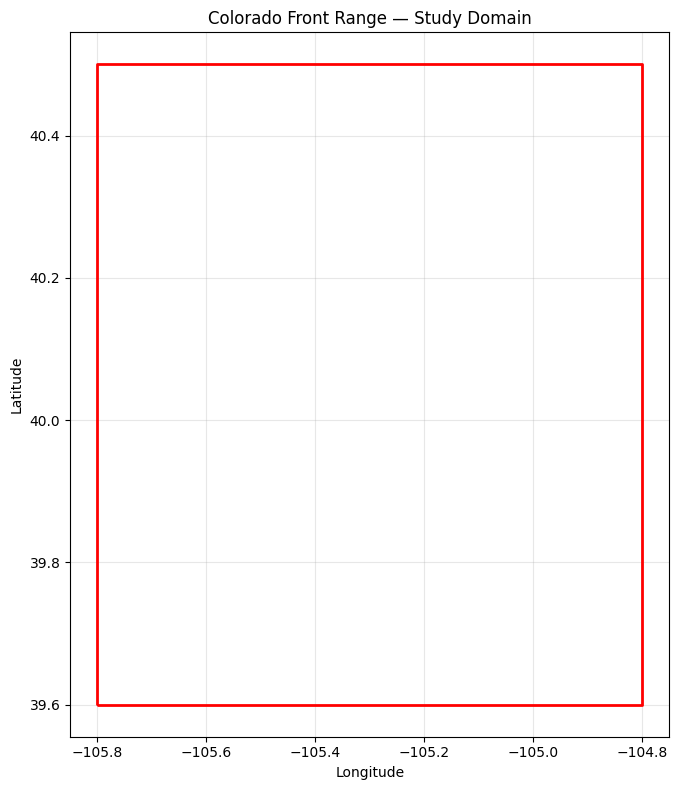


Study area extent: lon [-105.800, -104.800], lat [39.600, 40.500]


In [4]:
study_area = gpd.read_file(os.path.join(BBOX_DIR, 'colorado_front_range_domain.shp'))

print(f"CRS:    {study_area.crs}")
print(f"Bounds: {study_area.total_bounds}")
print(f"Columns: {list(study_area.columns)}")
print(study_area)

fig, ax = plt.subplots(figsize=(8, 8))
study_area.boundary.plot(ax=ax, color='red', linewidth=2)
ax.set_title('Colorado Front Range — Study Domain')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Store bounds for clipping later
bbox_geom = study_area.geometry.values
minx, miny, maxx, maxy = study_area.total_bounds
print(f"\nStudy area extent: lon [{minx:.3f}, {maxx:.3f}], lat [{miny:.3f}, {maxy:.3f}]")

## 3. ASTER DEM (30m, Static)

The ASTER Global DEM v3 provides elevation data at ~30m resolution. Four tiles cover our study area (N39–N40, W105–W106). We'll mosaic them and clip to the study domain.

In [5]:
# List all ASTER DEM files (skip the *_num.tif quality files)
dem_files = sorted(glob.glob(os.path.join(ASTER_DIR, '*_dem.tif')))
print(f"DEM tiles: {len(dem_files)}")

for f in dem_files:
    with rasterio.open(f) as src:
        data = src.read(1)
        print(f"  {os.path.basename(f)}: {src.height}x{src.width}, "
              f"res={src.res}, CRS={src.crs}, "
              f"elevation range=[{data.min()}, {data.max()}]m")

DEM tiles: 4
  ASTGTMV003_N39W105_dem.tif: 3601x3601, res=(0.000277777777777778, 0.000277777777777778), CRS=EPSG:4326, elevation range=[1438, 2858]m
  ASTGTMV003_N39W106_dem.tif: 3601x3601, res=(0.000277777777777778, 0.000277777777777778), CRS=EPSG:4326, elevation range=[1550, 4342]m
  ASTGTMV003_N40W105_dem.tif: 3601x3601, res=(0.000277777777777778, 0.000277777777777778), CRS=EPSG:4326, elevation range=[1318, 1994]m
  ASTGTMV003_N40W106_dem.tif: 3601x3601, res=(0.000277777777777778, 0.000277777777777778), CRS=EPSG:4326, elevation range=[1461, 4322]m


Mosaic shape: (7201, 7201)
Elevation range: 1318m to 4342m


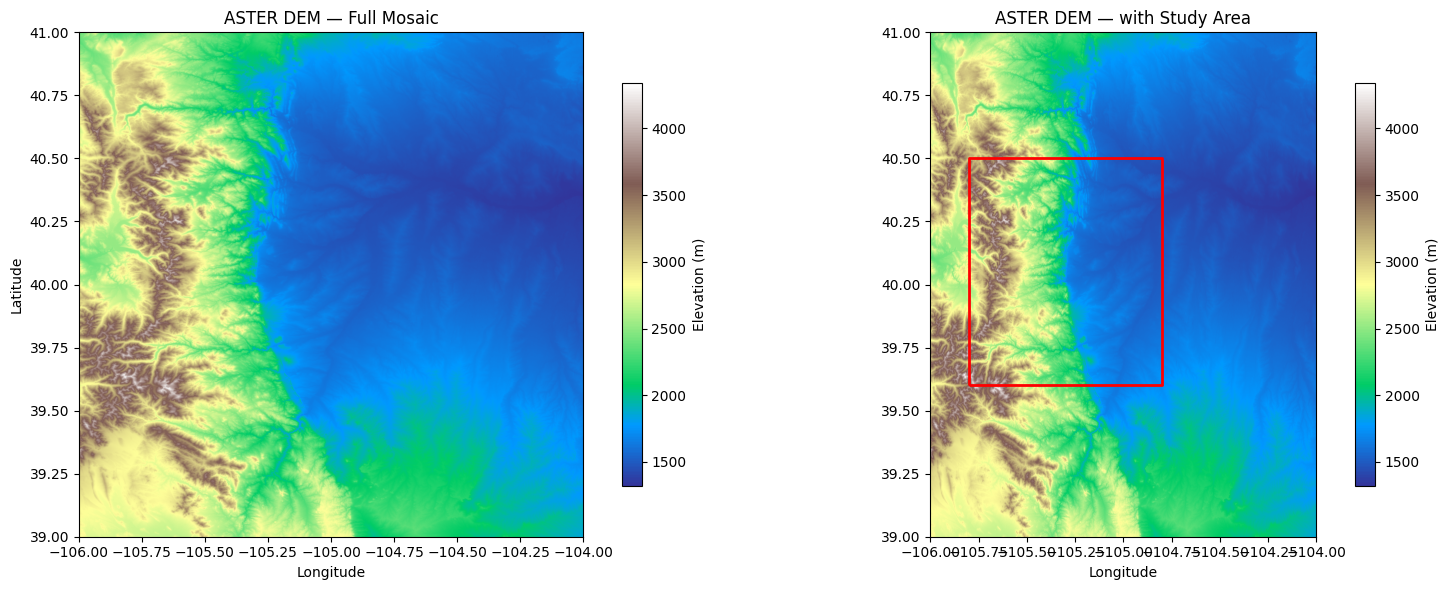

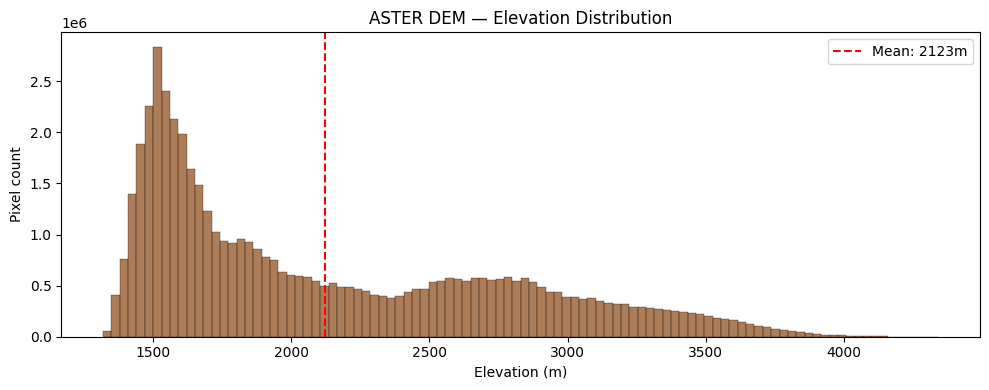

In [6]:
# Mosaic all DEM tiles into a single raster
src_files = [rasterio.open(f) for f in dem_files]
dem_mosaic, dem_transform = merge(src_files)
dem_crs = src_files[0].crs
for s in src_files:
    s.close()

dem_mosaic = dem_mosaic[0]  # single band
print(f"Mosaic shape: {dem_mosaic.shape}")
print(f"Elevation range: {dem_mosaic.min()}m to {dem_mosaic.max()}m")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full mosaic
im0 = axes[0].imshow(dem_mosaic, cmap='terrain',
                       extent=[dem_transform[2],
                               dem_transform[2] + dem_transform[0] * dem_mosaic.shape[1],
                               dem_transform[5] + dem_transform[4] * dem_mosaic.shape[0],
                               dem_transform[5]])
axes[0].set_title('ASTER DEM — Full Mosaic')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(im0, ax=axes[0], label='Elevation (m)', shrink=0.8)

# Plot with study area overlay
im1 = axes[1].imshow(dem_mosaic, cmap='terrain',
                       extent=[dem_transform[2],
                               dem_transform[2] + dem_transform[0] * dem_mosaic.shape[1],
                               dem_transform[5] + dem_transform[4] * dem_mosaic.shape[0],
                               dem_transform[5]])
study_area.boundary.plot(ax=axes[1], color='red', linewidth=2)
axes[1].set_title('ASTER DEM — with Study Area')
axes[1].set_xlabel('Longitude')
plt.colorbar(im1, ax=axes[1], label='Elevation (m)', shrink=0.8)

plt.tight_layout()
plt.show()

# Elevation histogram
fig, ax = plt.subplots(figsize=(10, 4))
valid = dem_mosaic[dem_mosaic > -100]
ax.hist(valid.ravel(), bins=100, color='saddlebrown', alpha=0.7, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Pixel count')
ax.set_title('ASTER DEM — Elevation Distribution')
ax.axvline(valid.mean(), color='red', linestyle='--', label=f'Mean: {valid.mean():.0f}m')
ax.legend()
plt.tight_layout()
plt.show()

## 4. LULC — NLCD Land Cover (30m, Annual)

National Land Cover Database provides land use/land cover classifications at 30m. We have annual maps for 2021–2024.

In [7]:
# NLCD class legend
NLCD_CLASSES = {
    11: ('Open Water', '#476BA0'),
    12: ('Perennial Ice/Snow', '#D1DDF9'),
    21: ('Developed, Open Space', '#DDC9C9'),
    22: ('Developed, Low Intensity', '#D89382'),
    23: ('Developed, Medium Intensity', '#ED0000'),
    24: ('Developed, High Intensity', '#AA0000'),
    31: ('Barren Land', '#B2ADA3'),
    41: ('Deciduous Forest', '#68AB63'),
    42: ('Evergreen Forest', '#1C6330'),
    43: ('Mixed Forest', '#B5C98E'),
    51: ('Dwarf Scrub', '#A58C30'),
    52: ('Shrub/Scrub', '#CCBA7C'),
    71: ('Grassland/Herbaceous', '#E2E2C1'),
    72: ('Sedge/Herbaceous', '#C9C977'),
    73: ('Lichens', '#99C147'),
    74: ('Moss', '#77AD93'),
    81: ('Pasture/Hay', '#DBD83D'),
    82: ('Cultivated Crops', '#AA7028'),
    90: ('Woody Wetlands', '#BAD8EA'),
    95: ('Emergent Herbaceous Wetlands', '#70A3BA'),
}

lulc_files = sorted(glob.glob(os.path.join(LULC_DIR, 'Annual_NLCD_LndCov_*.tiff')))
print(f"LULC files: {len(lulc_files)}")
for f in lulc_files:
    year = os.path.basename(f).split('_')[3]
    with rasterio.open(f) as src:
        print(f"  {year}: {src.height}x{src.width}, res={src.res}, CRS={src.crs}")

LULC files: 4
  2021: 3620x3132, res=(30.0, 30.0), CRS=PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  2022: 3620x3132, res=(30.0, 30.0), CRS=PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude

In [8]:
# Visualize LULC for 2022 (our study period)
lulc_2022 = [f for f in lulc_files if '2022' in os.path.basename(f)][0]

with rasterio.open(lulc_2022) as src:
    lulc_data = src.read(1)
    lulc_transform = src.transform
    lulc_crs = src.crs
    lulc_bounds = src.bounds

print(f"LULC 2022 shape: {lulc_data.shape}")
print(f"Unique classes: {np.unique(lulc_data)}")

# Count pixels per class
unique, counts = np.unique(lulc_data, return_counts=True)
print(f"\nClass distribution:")
for cls, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    name = NLCD_CLASSES.get(cls, ('Unknown', '#000000'))[0]
    pct = 100 * cnt / counts.sum()
    if pct > 0.5:
        print(f"  {cls:3d} {name:35s} {pct:6.1f}% ({cnt:,} pixels)")

LULC 2022 shape: (3620, 3132)
Unique classes: [ 11  12  21  22  23  24  31  41  42  43  52  71  81  82  90  95 250]

Class distribution:
   42 Evergreen Forest                      28.4% (3,222,282 pixels)
  250 Unknown                               16.4% (1,863,111 pixels)
   71 Grassland/Herbaceous                  12.1% (1,369,914 pixels)
   52 Shrub/Scrub                            9.8% (1,109,773 pixels)
   22 Developed, Low Intensity               8.5% (962,317 pixels)
   82 Cultivated Crops                       7.5% (854,653 pixels)
   23 Developed, Medium Intensity            6.3% (714,876 pixels)
   21 Developed, Open Space                  3.1% (350,458 pixels)
   31 Barren Land                            1.8% (199,952 pixels)
   95 Emergent Herbaceous Wetlands           1.7% (194,111 pixels)
   11 Open Water                             1.3% (148,606 pixels)
   81 Pasture/Hay                            1.0% (114,920 pixels)
   24 Developed, High Intensity              1.0% (

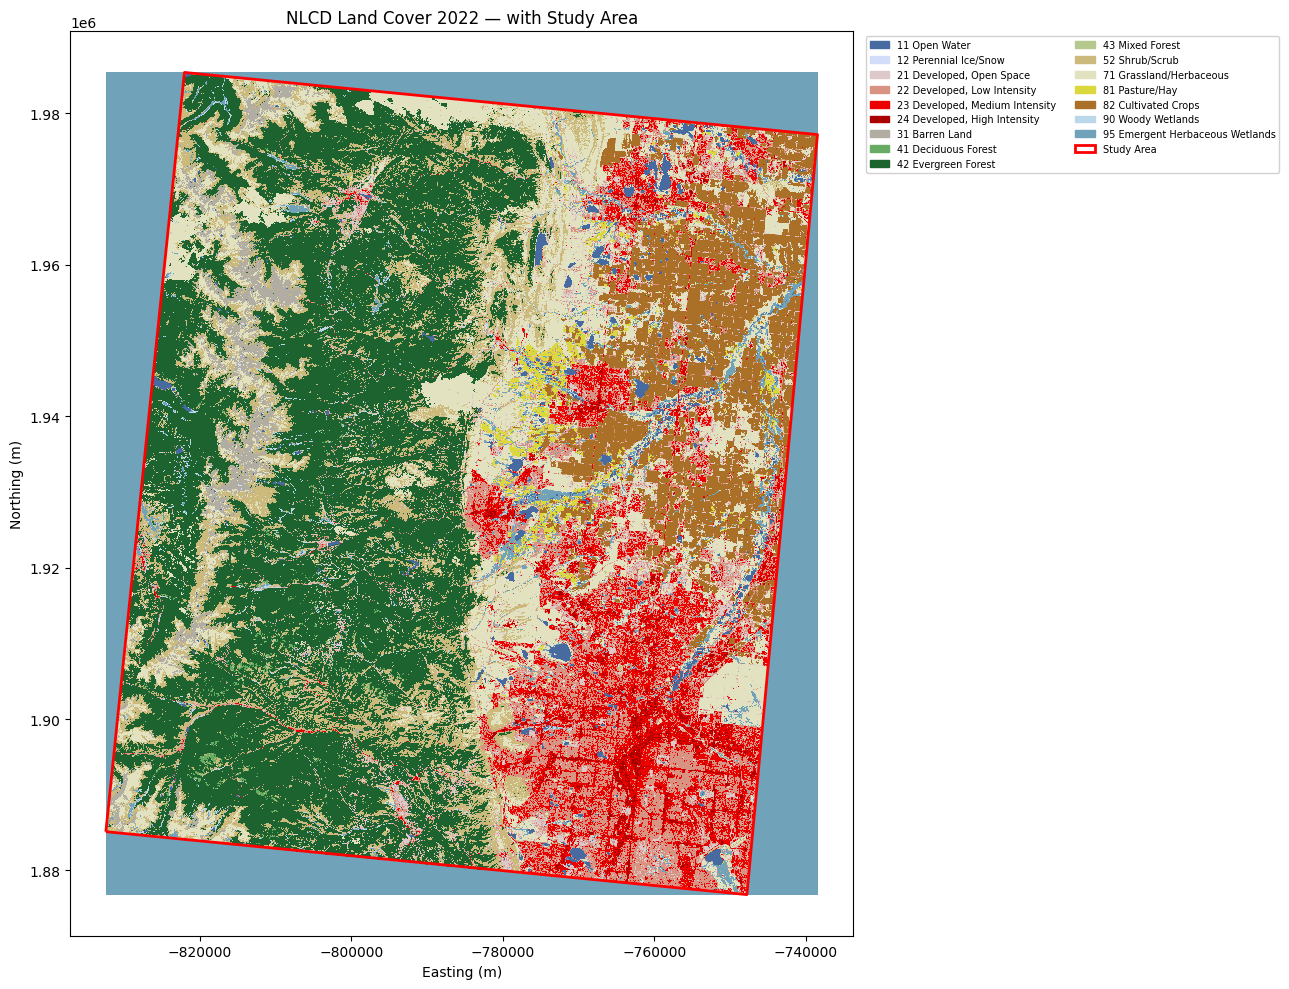

In [9]:
# Plot LULC map with proper NLCD colors + bounding box overlay
from matplotlib.colors import ListedColormap, BoundaryNorm

# Build colormap from NLCD classes present in data
classes_present = sorted([c for c in np.unique(lulc_data) if c in NLCD_CLASSES])
colors = [NLCD_CLASSES[c][1] for c in classes_present]
cmap = ListedColormap(colors)
bounds = classes_present + [classes_present[-1] + 1]
norm = BoundaryNorm(bounds, cmap.N)

# Reproject bounding box to LULC CRS for overlay
bbox_lulc = study_area.to_crs(lulc_crs)

fig, ax = plt.subplots(figsize=(14, 10))
extent = [lulc_bounds.left, lulc_bounds.right, lulc_bounds.bottom, lulc_bounds.top]
im = ax.imshow(lulc_data, cmap=cmap, norm=norm, extent=extent, interpolation='nearest')
bbox_lulc.boundary.plot(ax=ax, color='red', linewidth=2, label='Study Area')
ax.set_title('NLCD Land Cover 2022 — with Study Area')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# Add legend
patches = [mpatches.Patch(color=NLCD_CLASSES[c][1], label=f"{c} {NLCD_CLASSES[c][0]}")
           for c in classes_present]
patches.append(mpatches.Patch(edgecolor='red', facecolor='none', linewidth=2, label='Study Area'))
ax.legend(handles=patches, loc='upper left', fontsize=7, ncol=2,
          framealpha=0.9, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 5. MODIS MOD11A1 — Land Surface Temperature (1km, Daily)

MOD11A1 provides daily daytime and nighttime LST at 1km resolution in HDF-EOS format. Each file covers one MODIS sinusoidal tile. Our study area spans tiles **h09v04**, **h09v05**, and **h10v04**.

Key SDS layers:
- `LST_Day_1km` — Daytime LST (scale factor 0.02, units: Kelvin)
- `LST_Night_1km` — Nighttime LST
- `QC_Day` / `QC_Night` — Quality control flags
- `Emis_31` / `Emis_32` — Emissivity bands

In [10]:
# Inventory MODIS HDF files
modis_hdf = sorted(glob.glob(os.path.join(MODIS_DIR, 'MOD11A1.*.hdf')))
print(f"Total MODIS HDF files: {len(modis_hdf)}")

# Parse file naming: MOD11A1.A{YYYYDDD}.h{HH}v{VV}.061.{timestamp}.hdf
import re
from datetime import datetime, timedelta

tiles = set()
dates = []
for f in modis_hdf:
    fname = os.path.basename(f)
    m = re.match(r'MOD11A1\.A(\d{7})\.(h\d{2}v\d{2})\.', fname)
    if m:
        doy_str, tile = m.groups()
        tiles.add(tile)
        year = int(doy_str[:4])
        doy = int(doy_str[4:])
        date = datetime(year, 1, 1) + timedelta(days=doy - 1)
        dates.append(date)

dates = sorted(set(dates))
print(f"Tiles: {sorted(tiles)}")
print(f"Date range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")
print(f"Unique dates: {len(dates)}")
print(f"Files per tile: ~{len(modis_hdf) // len(tiles)}")

Total MODIS HDF files: 63
Tiles: ['h09v04', 'h09v05', 'h10v04']
Date range: 2022-01-01 to 2022-01-21
Unique dates: 21
Files per tile: ~21


In [11]:
# Examine one MODIS HDF file in detail
sample_hdf = modis_hdf[0]
print(f"Sample file: {os.path.basename(sample_hdf)}")
print(f"File size: {os.path.getsize(sample_hdf) / 1024:.0f} KB\n")

hdf = SD(sample_hdf, SDC.READ)
print("Available Scientific Data Sets (SDS):")
for name, info in hdf.datasets().items():
    dims, shape, dtype, nattrs = info
    print(f"  {name:30s} shape={shape} type={dtype}")

# Read and examine LST_Day_1km
lst_sds = hdf.select('LST_Day_1km')
lst_data = lst_sds.get()
attrs = lst_sds.attributes()
print(f"\nLST_Day_1km attributes:")
for k, v in attrs.items():
    print(f"  {k}: {v}")

scale = attrs.get('scale_factor', 0.02)
valid_range = attrs.get('valid_range', [7500, 65535])
fill_value = attrs.get('_FillValue', 0)

# Convert to Celsius
lst_valid = np.where((lst_data >= valid_range[0]) & (lst_data <= valid_range[1]),
                     lst_data * scale - 273.15, np.nan)

print(f"\nLST Day (Celsius): min={np.nanmin(lst_valid):.1f}, "
      f"max={np.nanmax(lst_valid):.1f}, "
      f"mean={np.nanmean(lst_valid):.1f}")
print(f"Valid pixel fraction: {np.sum(~np.isnan(lst_valid)) / lst_valid.size:.1%}")

hdf.end()

Sample file: MOD11A1.A2022001.h09v04.061.2022004025029.hdf
File size: 4753 KB

Available Scientific Data Sets (SDS):
  LST_Day_1km                    shape=(1200, 1200) type=23
  QC_Day                         shape=(1200, 1200) type=21
  Day_view_time                  shape=(1200, 1200) type=21
  Day_view_angl                  shape=(1200, 1200) type=21
  LST_Night_1km                  shape=(1200, 1200) type=23
  QC_Night                       shape=(1200, 1200) type=21
  Night_view_time                shape=(1200, 1200) type=21
  Night_view_angl                shape=(1200, 1200) type=21
  Emis_31                        shape=(1200, 1200) type=21
  Emis_32                        shape=(1200, 1200) type=21
  Clear_day_cov                  shape=(1200, 1200) type=23
  Clear_night_cov                shape=(1200, 1200) type=23

LST_Day_1km attributes:
  long_name: Daily daytime 1km grid Land-surface Temperature
  units: K
  Number Type: uint16
  valid_range: [7500, 65535]
  _FillValue: 0

Mosaicing 3 MODIS tiles for A2022001...
  h09v04: UL=(-10007555, 5559753), res=(926.6, -926.6)
  h09v05: UL=(-10007555, 4447802), res=(926.6, -926.6)
  h10v04: UL=(-8895604, 5559753), res=(926.6, -926.6)
Mosaic shape: (2400, 2400)


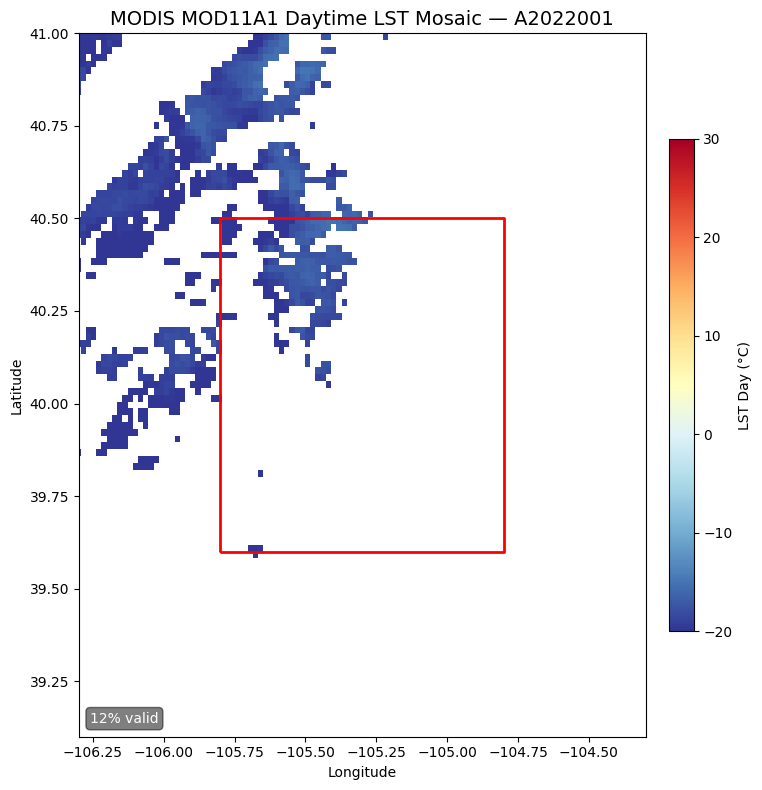

In [12]:
def read_modis_lst(hdf_path, layer='LST_Day_1km'):
    """Read MODIS LST from HDF and convert to Celsius."""
    hdf = SD(hdf_path, SDC.READ)
    sds = hdf.select(layer)
    data = sds.get().astype(np.float64)
    attrs = sds.attributes()
    scale = attrs.get('scale_factor', 0.02)
    valid_range = attrs.get('valid_range', [7500, 65535])
    data = np.where((data >= valid_range[0]) & (data <= valid_range[1]),
                    data * scale - 273.15, np.nan)
    hdf.end()
    return data

def read_modis_geotransform(hdf_path):
    """Extract sinusoidal geotransform from MODIS HDF metadata."""
    hdf = SD(hdf_path, SDC.READ)
    meta = hdf.attributes().get('StructMetadata.0', '')
    hdf.end()
    import re as _re
    ul = _re.search(r'UpperLeftPointMtrs=\(([-\d.]+),([-\d.]+)\)', meta)
    lr = _re.search(r'LowerRightMtrs=\(([-\d.]+),([-\d.]+)\)', meta)
    ul_x, ul_y = float(ul.group(1)), float(ul.group(2))
    lr_x, lr_y = float(lr.group(1)), float(lr.group(2))
    nrows, ncols = 1200, 1200
    res_x = (lr_x - ul_x) / ncols
    res_y = (lr_y - ul_y) / nrows  # negative
    return ul_x, ul_y, res_x, res_y, nrows, ncols

# MODIS sinusoidal CRS
MODIS_CRS = '+proj=sinu +R=6371007.181 +lon_0=0 +x_0=0 +y_0=0 +units=m +no_defs'

# Pick one day and mosaic all tiles
sample_date = os.path.basename(modis_hdf[0]).split('.')[1]
day_files = sorted([f for f in modis_hdf if sample_date in os.path.basename(f)])
print(f"Mosaicing {len(day_files)} MODIS tiles for {sample_date}...")

# Read each tile's LST + geotransform
tiles_data = []
for f in day_files:
    lst = read_modis_lst(f)
    ul_x, ul_y, res_x, res_y, nrows, ncols = read_modis_geotransform(f)
    tiles_data.append((lst, ul_x, ul_y, res_x, res_y))
    tile_id = re.search(r'(h\d{2}v\d{2})', os.path.basename(f)).group(1)
    print(f"  {tile_id}: UL=({ul_x:.0f}, {ul_y:.0f}), res=({res_x:.1f}, {res_y:.1f})")

# Compute combined bounding box
res_x = tiles_data[0][3]
res_y = tiles_data[0][4]
all_ul_x = [t[1] for t in tiles_data]
all_ul_y = [t[2] for t in tiles_data]
all_lr_x = [t[1] + res_x * t[0].shape[1] for t in tiles_data]
all_lr_y = [t[2] + res_y * t[0].shape[0] for t in tiles_data]

mos_ul_x, mos_ul_y = min(all_ul_x), max(all_ul_y)
mos_lr_x, mos_lr_y = max(all_lr_x), min(all_lr_y)
mos_cols = int(round((mos_lr_x - mos_ul_x) / res_x))
mos_rows = int(round((mos_lr_y - mos_ul_y) / res_y))

# Paste tiles into mosaic
lst_mosaic = np.full((mos_rows, mos_cols), np.nan, dtype=np.float64)
for lst, ul_x, ul_y, _, _ in tiles_data:
    col_off = int(round((ul_x - mos_ul_x) / res_x))
    row_off = int(round((ul_y - mos_ul_y) / res_y))
    lst_mosaic[row_off:row_off + lst.shape[0], col_off:col_off + lst.shape[1]] = lst

print(f"Mosaic shape: {lst_mosaic.shape}")

# Build rasterio-compatible transform for the mosaic
from rasterio.transform import from_origin
mosaic_transform = from_origin(mos_ul_x, mos_ul_y, abs(res_x), abs(res_y))

# Reproject mosaic to EPSG:4326
dst_crs = 'EPSG:4326'
dst_transform, dst_width, dst_height = calculate_default_transform(
    MODIS_CRS, dst_crs, mos_cols, mos_rows,
    left=mos_ul_x, bottom=mos_lr_y, right=mos_lr_x, top=mos_ul_y,
)

lst_reproj = np.full((dst_height, dst_width), np.nan, dtype=np.float64)
reproject(
    source=lst_mosaic,
    destination=lst_reproj,
    src_transform=mosaic_transform,
    src_crs=MODIS_CRS,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    resampling=Resampling.nearest,
    src_nodata=np.nan,
    dst_nodata=np.nan,
)

extent_ll = [
    dst_transform[2],
    dst_transform[2] + dst_transform[0] * dst_width,
    dst_transform[5] + dst_transform[4] * dst_height,
    dst_transform[5],
]

# Zoom to study area with padding
pad = 0.5  # degrees
sa_minx, sa_miny, sa_maxx, sa_maxy = study_area.total_bounds

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(lst_reproj, cmap='RdYlBu_r', vmin=-20, vmax=30, extent=extent_ll)
study_area.boundary.plot(ax=ax, color='red', linewidth=2)
fig.colorbar(im, ax=ax, label='LST Day (°C)', shrink=0.7, pad=0.02)
ax.set_xlim(sa_minx - pad, sa_maxx + pad)
ax.set_ylim(sa_miny - pad, sa_maxy + pad)
ax.set_title(f'MODIS MOD11A1 Daytime LST Mosaic — {sample_date}', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

valid_pct = np.sum(~np.isnan(lst_reproj)) / lst_reproj.size * 100
ax.text(0.02, 0.02, f'{valid_pct:.0f}% valid', transform=ax.transAxes,
        fontsize=10, color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.show()

del lst_mosaic, lst_reproj, tiles_data

Scanning MODIS temporal coverage (this may take a minute)...


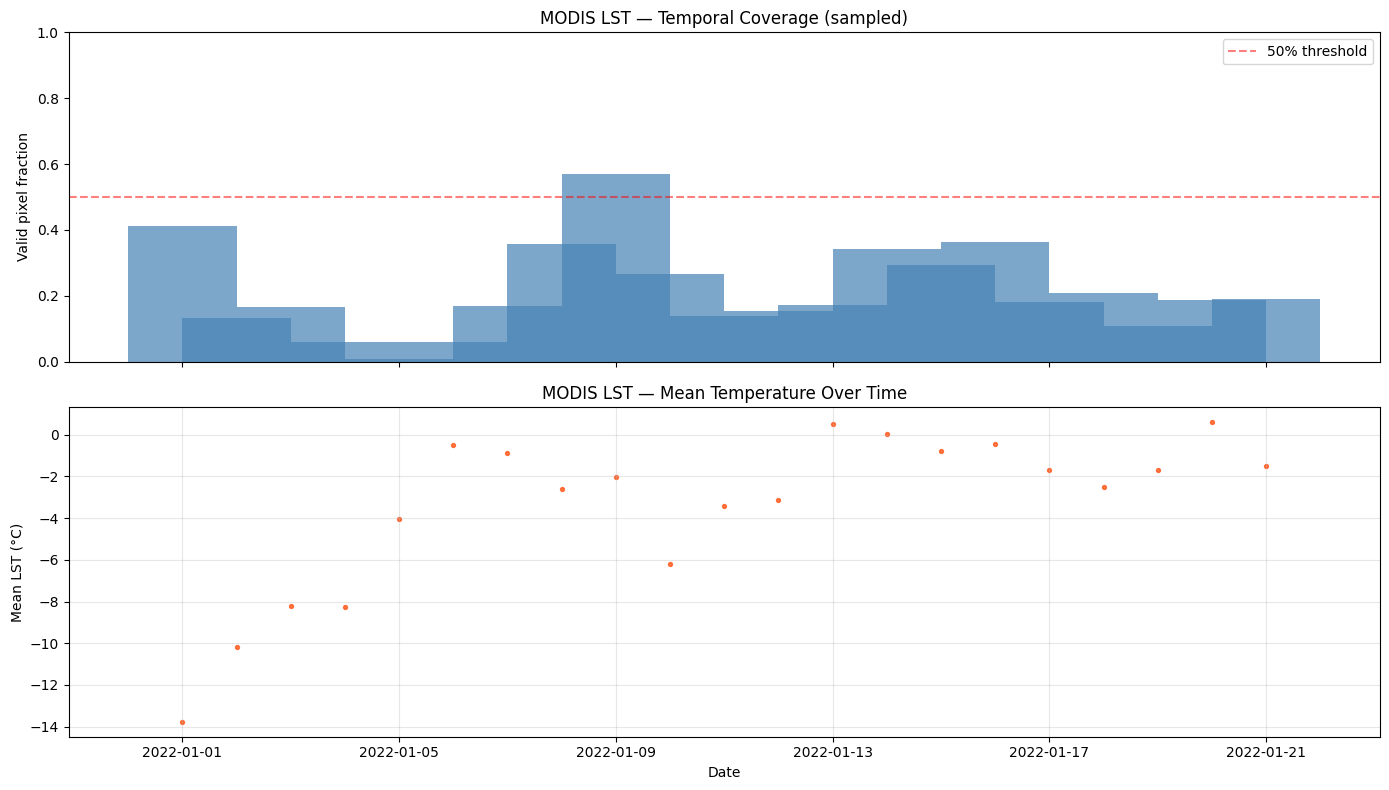


Scanned 21 files across 21 dates
Mean valid fraction: 21.6%
LST range: -13.8°C to 0.6°C


In [13]:
# Temporal coverage: count valid pixels per day across all tiles
print("Scanning MODIS temporal coverage (this may take a minute)...")

from collections import defaultdict
daily_stats = defaultdict(lambda: {'valid': 0, 'total': 0, 'mean_lst': []})

# Sample every 10th date for speed
sampled_files = modis_hdf[::3]  # every 3rd file
for f in sampled_files:
    fname = os.path.basename(f)
    m = re.match(r'MOD11A1\.A(\d{7})\.(h\d{2}v\d{2})\.', fname)
    if not m:
        continue
    doy_str = m.group(1)
    year = int(doy_str[:4])
    doy = int(doy_str[4:])
    date = datetime(year, 1, 1) + timedelta(days=doy - 1)

    lst = read_modis_lst(f)
    valid = np.sum(~np.isnan(lst))
    daily_stats[date]['valid'] += valid
    daily_stats[date]['total'] += lst.size
    if valid > 0:
        daily_stats[date]['mean_lst'].append(np.nanmean(lst))

# Plot temporal coverage
sorted_dates = sorted(daily_stats.keys())
valid_fracs = [daily_stats[d]['valid'] / daily_stats[d]['total'] for d in sorted_dates]
mean_lsts = [np.mean(daily_stats[d]['mean_lst']) if daily_stats[d]['mean_lst'] else np.nan
             for d in sorted_dates]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.bar(sorted_dates, valid_fracs, width=2, color='steelblue', alpha=0.7)
ax1.set_ylabel('Valid pixel fraction')
ax1.set_title('MODIS LST — Temporal Coverage (sampled)')
ax1.set_ylim(0, 1)
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax1.legend()

ax2.scatter(sorted_dates, mean_lsts, s=8, c='orangered', alpha=0.7)
ax2.set_ylabel('Mean LST (°C)')
ax2.set_xlabel('Date')
ax2.set_title('MODIS LST — Mean Temperature Over Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nScanned {len(sampled_files)} files across {len(sorted_dates)} dates")
print(f"Mean valid fraction: {np.mean(valid_fracs):.1%}")
print(f"LST range: {np.nanmin(mean_lsts):.1f}°C to {np.nanmax(mean_lsts):.1f}°C")

## 6. Sentinel-2 (10m, ~Bimonthly)

Sentinel-2 bands B03 (Green), B04 (Red), B08 (NIR) at 10m resolution. These are used to compute:
- **NDVI** = (B08 - B04) / (B08 + B04) — vegetation index
- **NDWI** = (B03 - B08) / (B03 + B08) — water/moisture index

Files are organized as individual band TIFs per date and tile (T13SDD, T13SED, T13TDE, T13TEE).

In [14]:
# Inventory Sentinel-2 files
sen2_files = sorted(glob.glob(os.path.join(SEN2_DIR, '*.tif')))
print(f"Total Sentinel-2 TIF files: {len(sen2_files)}")

# Parse naming: S2A_MSIL2A_{date}T{time}_{orbit}_{tile}_{procdate}_{band}.tif
sen2_dates = set()
sen2_tiles = set()
sen2_bands = set()
for f in sen2_files:
    fname = os.path.basename(f)
    parts = fname.replace('.tif', '').split('_')
    date_str = parts[2][:8]  # YYYYMMDD
    tile = parts[4]          # e.g. T13SDD
    band = parts[-1]
    sen2_dates.add(date_str)
    sen2_tiles.add(tile)
    sen2_bands.add(band)

print(f"Tiles: {sorted(sen2_tiles)}")
print(f"Bands: {sorted(sen2_bands)}")
print(f"Unique dates: {len(sen2_dates)}")
print(f"Date range: {min(sen2_dates)} to {max(sen2_dates)}")
print(f"Scenes (date x tile): {len(sen2_files) // len(sen2_bands)}")

# Show first few dates
print(f"\nFirst 10 dates: {sorted(sen2_dates)[:10]}")

Total Sentinel-2 TIF files: 6
Tiles: ['T13SDD', 'T13SED']
Bands: ['B03', 'B04', 'B08']
Unique dates: 1
Date range: 20220128 to 20220128
Scenes (date x tile): 2

First 10 dates: ['20220128']


In [15]:
# Examine one Sentinel-2 tile to show metadata
sample_sen2_date = sorted(sen2_dates)[0]
sample_sen2_tile = sorted(sen2_tiles)[0]

def find_sen2_band(date, tile, band, files):
    """Find the Sentinel-2 file for a given date, tile, band."""
    for f in files:
        fname = os.path.basename(f)
        parts = fname.replace('.tif', '').split('_')
        f_date = parts[2][:8]
        f_tile = parts[4]
        f_band = parts[-1]
        if f_date == date and f_tile == tile and f_band == band:
            return f
    return None

b03_file = find_sen2_band(sample_sen2_date, sample_sen2_tile, 'B03', sen2_files)
b04_file = find_sen2_band(sample_sen2_date, sample_sen2_tile, 'B04', sen2_files)
b08_file = find_sen2_band(sample_sen2_date, sample_sen2_tile, 'B08', sen2_files)

print(f"Sample scene: {sample_sen2_date}, tile {sample_sen2_tile}")

with rasterio.open(b03_file) as src:
    b03_shape = (src.height, src.width)
    print(f"  B03 (Green): shape={b03_shape}, CRS={src.crs}, res={src.res}")
    print(f"  Bounds: {src.bounds}")

with rasterio.open(b04_file) as src:
    print(f"  B04 (Red):   shape=({src.height}, {src.width})")

with rasterio.open(b08_file) as src:
    print(f"  B08 (NIR):   shape=({src.height}, {src.width})")

Sample scene: 20220128, tile T13SDD
  B03 (Green): shape=(10980, 10980), CRS=EPSG:32613, res=(10.0, 10.0)
  Bounds: BoundingBox(left=399960.0, bottom=4290240.0, right=509760.0, top=4400040.0)
  B04 (Red):   shape=(10980, 10980)
  B08 (NIR):   shape=(10980, 10980)


Mosaicing Sentinel-2 for 20220128, tiles: ['T13SDD', 'T13SED']
Mosaic shape: (1098, 2098) (decimated 10x from 10m → 100m), CRS: EPSG:32613


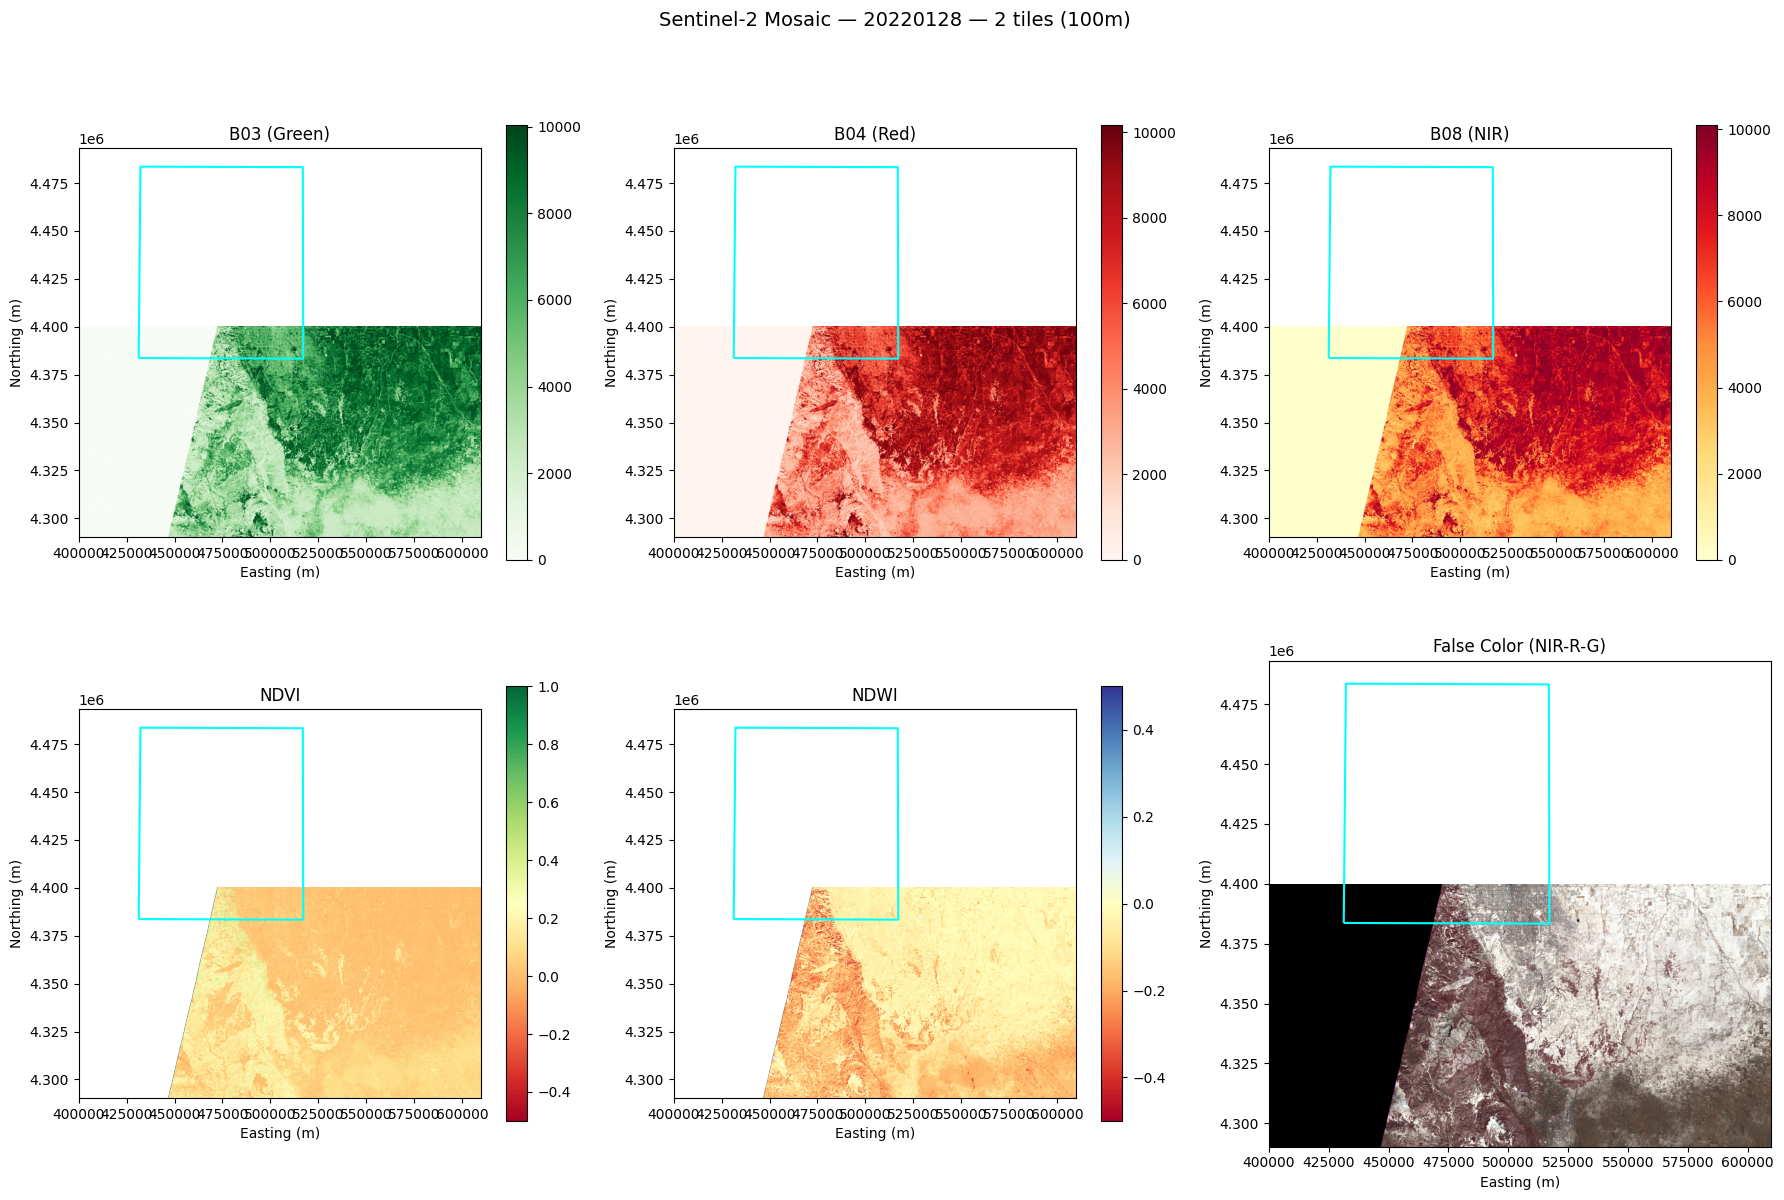

In [16]:
# Mosaic all Sentinel-2 tiles for the first date, then plot with bounding box
# Use decimated reads (reduced resolution) to avoid Colab OOM on 10m rasters
sample_sen2_date = sorted(sen2_dates)[0]
date_files = [f for f in sen2_files if sample_sen2_date in os.path.basename(f)]
tiles_for_date = sorted(set(
    os.path.basename(f).replace('.tif', '').split('_')[4] for f in date_files
))
print(f"Mosaicing Sentinel-2 for {sample_sen2_date}, tiles: {tiles_for_date}")

# Decimation factor: read every Nth pixel to keep each tile under ~1024px
DECIM = 10  # 10m * 10 = 100m effective resolution

def mosaic_sen2_band_decimated(date, band, files, decim=DECIM):
    """Mosaic all tiles for a date/band, reading at reduced resolution."""
    band_files = sorted([f for f in files
                         if date in os.path.basename(f) and f.endswith(f'_{band}.tif')])
    if not band_files:
        return None, None, None

    arrays = []
    transforms = []
    crs = None
    for bf in band_files:
        with rasterio.open(bf) as src:
            crs = src.crs
            # Decimated read: output shape is full_size // decim
            out_h = max(1, src.height // decim)
            out_w = max(1, src.width // decim)
            data = src.read(1, out_shape=(out_h, out_w)).astype(np.float64)
            # Adjust transform to match decimated resolution
            t = src.transform
            new_transform = rasterio.transform.Affine(
                t.a * decim, t.b, t.c,
                t.d, t.e * decim, t.f,
            )
            arrays.append(data)
            transforms.append(new_transform)

    if len(arrays) == 1:
        return arrays[0], transforms[0], crs

    # Manual mosaic: compute combined extent
    all_ul_x = [t.c for t in transforms]
    all_ul_y = [t.f for t in transforms]
    res_x = transforms[0].a
    res_y = transforms[0].e  # negative
    all_lr_x = [t.c + t.a * a.shape[1] for t, a in zip(transforms, arrays)]
    all_lr_y = [t.f + t.e * a.shape[0] for t, a in zip(transforms, arrays)]

    mos_ul_x, mos_ul_y = min(all_ul_x), max(all_ul_y)
    mos_lr_x, mos_lr_y = max(all_lr_x), min(all_lr_y)
    mos_cols = int(round((mos_lr_x - mos_ul_x) / res_x))
    mos_rows = int(round((mos_lr_y - mos_ul_y) / res_y))

    mosaic = np.zeros((mos_rows, mos_cols), dtype=np.float64)
    for data, t in zip(arrays, transforms):
        col_off = int(round((t.c - mos_ul_x) / res_x))
        row_off = int(round((t.f - mos_ul_y) / res_y))
        mosaic[row_off:row_off + data.shape[0], col_off:col_off + data.shape[1]] = data

    mos_transform = rasterio.transform.Affine(res_x, 0, mos_ul_x, 0, res_y, mos_ul_y)
    return mosaic, mos_transform, crs

b03_mos, sen2_transform, sen2_crs = mosaic_sen2_band_decimated(sample_sen2_date, 'B03', sen2_files)
b04_mos, _, _ = mosaic_sen2_band_decimated(sample_sen2_date, 'B04', sen2_files)
b08_mos, _, _ = mosaic_sen2_band_decimated(sample_sen2_date, 'B08', sen2_files)

print(f"Mosaic shape: {b03_mos.shape} (decimated {DECIM}x from 10m → {DECIM*10}m), CRS: {sen2_crs}")

# Compute indices
ndvi_mos = np.where((b08_mos + b04_mos) > 0, (b08_mos - b04_mos) / (b08_mos + b04_mos), np.nan)
ndwi_mos = np.where((b03_mos + b08_mos) > 0, (b03_mos - b08_mos) / (b03_mos + b08_mos), np.nan)

# Reproject bounding box to Sentinel-2 CRS for overlay
bbox_sen2 = study_area.to_crs(sen2_crs)

# Compute extent in Sentinel-2 CRS
extent_s2 = [
    sen2_transform.c,
    sen2_transform.c + sen2_transform.a * b03_mos.shape[1],
    sen2_transform.f + sen2_transform.e * b03_mos.shape[0],
    sen2_transform.f,
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: raw bands
for ax, data, name, cmap in zip(axes[0],
                                  [b03_mos, b04_mos, b08_mos],
                                  ['B03 (Green)', 'B04 (Red)', 'B08 (NIR)'],
                                  ['Greens', 'Reds', 'YlOrRd']):
    vmax = np.percentile(data[data > 0], 98) if np.any(data > 0) else 1
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=vmax, extent=extent_s2)
    bbox_sen2.boundary.plot(ax=ax, color='cyan', linewidth=1.5)
    ax.set_title(name)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Row 2: NDVI, NDWI, false color composite
im_ndvi = axes[1][0].imshow(ndvi_mos, cmap='RdYlGn', vmin=-0.5, vmax=1, extent=extent_s2)
bbox_sen2.boundary.plot(ax=axes[1][0], color='cyan', linewidth=1.5)
axes[1][0].set_title('NDVI')
plt.colorbar(im_ndvi, ax=axes[1][0], shrink=0.8)

im_ndwi = axes[1][1].imshow(ndwi_mos, cmap='RdYlBu', vmin=-0.5, vmax=0.5, extent=extent_s2)
bbox_sen2.boundary.plot(ax=axes[1][1], color='cyan', linewidth=1.5)
axes[1][1].set_title('NDWI')
plt.colorbar(im_ndwi, ax=axes[1][1], shrink=0.8)

# False color composite (NIR-Red-Green)
rgb = np.stack([b08_mos, b04_mos, b03_mos], axis=-1)
p98 = np.percentile(rgb[rgb > 0], 98) if np.any(rgb > 0) else 1
rgb = np.clip(rgb / p98, 0, 1)
axes[1][2].imshow(rgb, extent=extent_s2)
bbox_sen2.boundary.plot(ax=axes[1][2], color='cyan', linewidth=1.5)
axes[1][2].set_title('False Color (NIR-R-G)')

for ax in axes.ravel():
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

plt.suptitle(f'Sentinel-2 Mosaic — {sample_sen2_date} — {len(tiles_for_date)} tiles ({DECIM*10}m)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

del b03_mos, b04_mos, b08_mos, ndvi_mos, ndwi_mos, rgb

## 7. Train / Val / Test Splits

The dataset includes `splits.csv` and `metadata.csv` with pre-defined temporal block splits:

| Split | Period | Purpose |
|-------|--------|---------|
| train | 2022 Jan–Sep | Training |
| val | 2022 Oct–Dec | Validation (seasonal shift) |
| test | 2023 | Temporal generalization |

Each row in `metadata.csv` is a MODIS date × tile sample matched to the nearest Sentinel-2, ASTER, and LULC.

In [17]:
import pandas as pd

metadata = pd.read_csv(os.path.join(DATA_ROOT, 'metadata.csv'))
print(f"Total samples: {len(metadata)}\n")
print(metadata.groupby('split').agg(
    samples=('date', 'count'),
    date_min=('date', 'min'),
    date_max=('date', 'max'),
    tiles=('modis_tile', 'nunique'),
))
print(f"\n{metadata.head()}")

Total samples: 2151

       samples    date_min    date_max  tiles
split                                        
test      1095  2023-01-01  2023-12-31      3
train      819  2022-01-01  2022-09-30      3
val        237  2022-10-01  2022-12-31      3

                                        modis_browse  \
0  MODIS/BROWSE.MOD11A1.A2022001.h09v04.061.20220...   
1  MODIS/BROWSE.MOD11A1.A2022001.h09v05.061.20220...   
2  MODIS/BROWSE.MOD11A1.A2022001.h10v04.061.20220...   
3  MODIS/BROWSE.MOD11A1.A2022002.h09v04.061.20220...   
4  MODIS/BROWSE.MOD11A1.A2022002.h09v05.061.20220...   

                                       sentinel2_b04  \
0  Sentinel2/S2B_MSIL2A_20220207T174509_R098_T13T...   
1  Sentinel2/S2B_MSIL2A_20220128T174559_R098_T13S...   
2  Sentinel2/S2B_MSIL2A_20220207T174509_R098_T13T...   
3  Sentinel2/S2B_MSIL2A_20220207T174509_R098_T13T...   
4  Sentinel2/S2B_MSIL2A_20220128T174559_R098_T13S...   

                              aster  \
0  ASTER/ASTGTMV003_N40W106_dem.tif

In [18]:
# ============================================================
# 8. Bicubic Interpolation Baseline (MODIS only)
# ============================================================

import os
import re
import cv2
import math
import numpy as np
import pandas as pd
import rasterio
from rasterio.io import MemoryFile
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.transform import from_origin
from pyhdf.SD import SD, SDC
from datetime import datetime, timedelta
from collections import defaultdict
import matplotlib.pyplot as plt

# If this line was cut off earlier, redefine it here safely
MODIS_CRS = '+proj=sinu +R=6371007.181 +nadgrids=@null +wktext +units=m +no_defs'


def read_modis_sds(hdf_path, layer_name):
    """Read any MODIS SDS from HDF as float64 array."""
    hdf = SD(hdf_path, SDC.READ)
    sds = hdf.select(layer_name)
    data = sds.get().astype(np.float64)
    attrs = sds.attributes()
    hdf.end()
    return data, attrs


def read_modis_lst_qc(hdf_path, lst_layer='LST_Day_1km', qc_layer='QC_Day', use_qc=True):
    """
    Read MODIS LST and optionally apply a simple QC mask.

    LST conversion:
        Celsius = raw * scale_factor - 273.15

    QC rule used here:
        Keep pixels where mandatory QA bits (0-1) are 00 or 01.
    This is a common simple baseline rule:
        00 = LST produced, good quality
        01 = LST produced, other quality
    """
    lst_raw, lst_attrs = read_modis_sds(hdf_path, lst_layer)
    scale = lst_attrs.get('scale_factor', 0.02)
    valid_range = lst_attrs.get('valid_range', [7500, 65535])

    # Valid physical range first
    lst_c = np.where(
        (lst_raw >= valid_range[0]) & (lst_raw <= valid_range[1]),
        lst_raw * scale - 273.15,
        np.nan
    )

    if use_qc:
        qc_raw, _ = read_modis_sds(hdf_path, qc_layer)
        qc_raw = qc_raw.astype(np.uint16)

        # Bits 0-1: mandatory QA flags
        mandatory_qa = qc_raw & 0b11

        # Keep good / acceptable produced pixels
        qc_mask = (mandatory_qa == 0) | (mandatory_qa == 1)
        lst_c = np.where(qc_mask, lst_c, np.nan)

    return lst_c


def modis_array_to_memfile(arr, transform, crs, nodata=np.nan):
    """Wrap a numpy array as an in-memory raster dataset for merge/mask."""
    memfile = MemoryFile()
    dataset = memfile.open(
        driver='GTiff',
        height=arr.shape[0],
        width=arr.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=nodata
    )
    dataset.write(arr.astype(np.float32), 1)
    return memfile, dataset


def parse_modis_date_tile(hdf_path):
    """
    Parse:
      MOD11A1.A2022001.h09v04.061....
    Returns:
      date_str = '2022001'
      tile = 'h09v04'
      date_obj = datetime
    """
    fname = os.path.basename(hdf_path)
    m = re.match(r'MOD11A1\.A(\d{7})\.(h\d{2}v\d{2})\.', fname)
    if m is None:
        return None, None, None

    date_str, tile = m.groups()
    year = int(date_str[:4])
    doy = int(date_str[4:])
    date_obj = datetime(year, 1, 1) + timedelta(days=doy - 1)
    return date_str, tile, date_obj


def build_modis_file_index(modis_files):
    """Map each date_str -> list of HDF paths."""
    by_date = defaultdict(list)
    for f in modis_files:
        date_str, tile, date_obj = parse_modis_date_tile(f)
        if date_str is not None:
            by_date[date_str].append(f)
    return dict(by_date)


def get_transform_from_hdf(hdf_path):
    """
    Convert MODIS metadata to rasterio Affine transform.
    """
    ul_x, ul_y, res_x, res_y, nrows, ncols = read_modis_geotransform(hdf_path)
    # from_origin expects positive y pixel size
    transform = from_origin(ul_x, ul_y, res_x, abs(res_y))
    return transform


def mosaic_and_clip_modis_for_date(date_str, modis_index, study_area_gdf, use_qc=True):
    """
    For one MODIS date:
      - read all tiles
      - convert LST to Celsius
      - build in-memory rasters
      - mosaic tiles
      - clip to study area
    Returns:
      clipped_arr, clipped_transform, clipped_crs
    """
    files = sorted(modis_index.get(date_str, []))
    if len(files) == 0:
        raise ValueError(f'No MODIS files found for date {date_str}')

    memfiles = []
    datasets = []

    try:
        for f in files:
            arr = read_modis_lst_qc(f, use_qc=use_qc)
            transform = get_transform_from_hdf(f)

            memfile, ds = modis_array_to_memfile(arr, transform, MODIS_CRS, nodata=np.nan)
            memfiles.append(memfile)
            datasets.append(ds)

        mosaic_arr, mosaic_transform = merge(datasets, nodata=np.nan)
        mosaic_arr = mosaic_arr[0]

        # Build a temporary mosaic dataset so we can clip with rasterio.mask
        temp_memfile, temp_ds = modis_array_to_memfile(mosaic_arr, mosaic_transform, MODIS_CRS, nodata=np.nan)

        # Reproject study area to MODIS sinusoidal CRS
        study_area_modis = study_area_gdf.to_crs(MODIS_CRS)

        clipped, clipped_transform = mask(
            temp_ds,
            study_area_modis.geometry,
            crop=True,
            nodata=np.nan
        )
        clipped = clipped[0]

        temp_ds.close()
        temp_memfile.close()

    finally:
        for ds in datasets:
            ds.close()
        for mf in memfiles:
            mf.close()

    return clipped, clipped_transform, MODIS_CRS


def nan_block_reduce_mean(arr, factor):
    """
    Downsample by block averaging, ignoring NaNs.
    Crops array so dimensions are divisible by factor.
    """
    h, w = arr.shape
    h2 = (h // factor) * factor
    w2 = (w // factor) * factor
    arr2 = arr[:h2, :w2]

    reshaped = arr2.reshape(h2 // factor, factor, w2 // factor, factor)
    coarse = np.nanmean(reshaped, axis=(1, 3))
    return coarse, h2, w2


def bicubic_upsample(arr, out_shape):
    """
    Bicubic upsampling using OpenCV.
    OpenCV can behave poorly with NaNs, so fill NaNs before resize
    and re-mask later.
    """
    arr_filled = arr.copy()
    valid = np.isfinite(arr_filled)

    if np.sum(valid) == 0:
        return np.full(out_shape, np.nan, dtype=np.float64)

    fill_value = np.nanmean(arr_filled)
    arr_filled[~valid] = fill_value

    out_h, out_w = out_shape
    up = cv2.resize(
        arr_filled.astype(np.float32),
        (out_w, out_h),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float64)

    return up


def compute_metrics(pred, target, mask):
    """Return RMSE, MAE, bias over valid mask."""
    diff = pred[mask] - target[mask]
    rmse = np.sqrt(np.mean(diff ** 2))
    mae = np.mean(np.abs(diff))
    bias = np.mean(diff)
    return rmse, mae, bias


def run_bicubic_on_scene(target_arr, factor=5, min_valid_fraction=0.50):
    """
    Synthetic baseline on one clipped MODIS scene:
      1km target -> 5km block average -> bicubic back to 1km

    Returns dict with arrays + metrics.
    """
    valid_frac = np.sum(np.isfinite(target_arr)) / target_arr.size
    if valid_frac < min_valid_fraction:
        return None

    coarse, h2, w2 = nan_block_reduce_mean(target_arr, factor)
    target_crop = target_arr[:h2, :w2]

    recon = bicubic_upsample(coarse, (h2, w2))

    # Only evaluate where original target is valid
    eval_mask = np.isfinite(target_crop)

    if np.sum(eval_mask) == 0:
        return None

    rmse, mae, bias = compute_metrics(recon, target_crop, eval_mask)

    return {
        'target': target_crop,
        'coarse': coarse,
        'recon': recon,
        'eval_mask': eval_mask,
        'rmse': rmse,
        'mae': mae,
        'bias': bias,
        'valid_fraction': valid_frac
    }

In [19]:
# Build date -> file list index
modis_index = build_modis_file_index(modis_hdf)

all_date_strs = sorted(modis_index.keys())
print(f'Total MODIS dates available: {len(all_date_strs)}')
print('First 10 dates:', all_date_strs[:10])

# Optional: convert to readable dates
all_dates_readable = []
for ds in all_date_strs[:10]:
    year = int(ds[:4])
    doy = int(ds[4:])
    dt = datetime(year, 1, 1) + timedelta(days=doy - 1)
    all_dates_readable.append(dt.strftime('%Y-%m-%d'))
print('First 10 readable dates:', all_dates_readable)

Total MODIS dates available: 21
First 10 dates: ['2022001', '2022002', '2022003', '2022004', '2022005', '2022006', '2022007', '2022008', '2022009', '2022010']
First 10 readable dates: ['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08', '2022-01-09', '2022-01-10']


In [27]:
# Pick one date to test first
sample_date = '2022002'
print('Testing sample MODIS date:', sample_date)

clipped_lst, clipped_transform, clipped_crs = mosaic_and_clip_modis_for_date(
    sample_date,
    modis_index,
    study_area,
    use_qc=True
)

print('Clipped MODIS shape:', clipped_lst.shape)
print('Clipped valid fraction:', np.sum(np.isfinite(clipped_lst)) / clipped_lst.size)

result = run_bicubic_on_scene(clipped_lst, factor=5, min_valid_fraction=0.20)

if result is None:
    print('Scene skipped because too many invalid pixels.')
else:
    print(f"RMSE: {result['rmse']:.3f} °C")
    print(f"MAE:  {result['mae']:.3f} °C")
    print(f"Bias: {result['bias']:.3f} °C")

Testing sample MODIS date: 2022002
Clipped MODIS shape: (109, 221)
Clipped valid fraction: 0.2918759599817344
RMSE: 0.894 °C
MAE:  0.669 °C
Bias: -0.018 °C


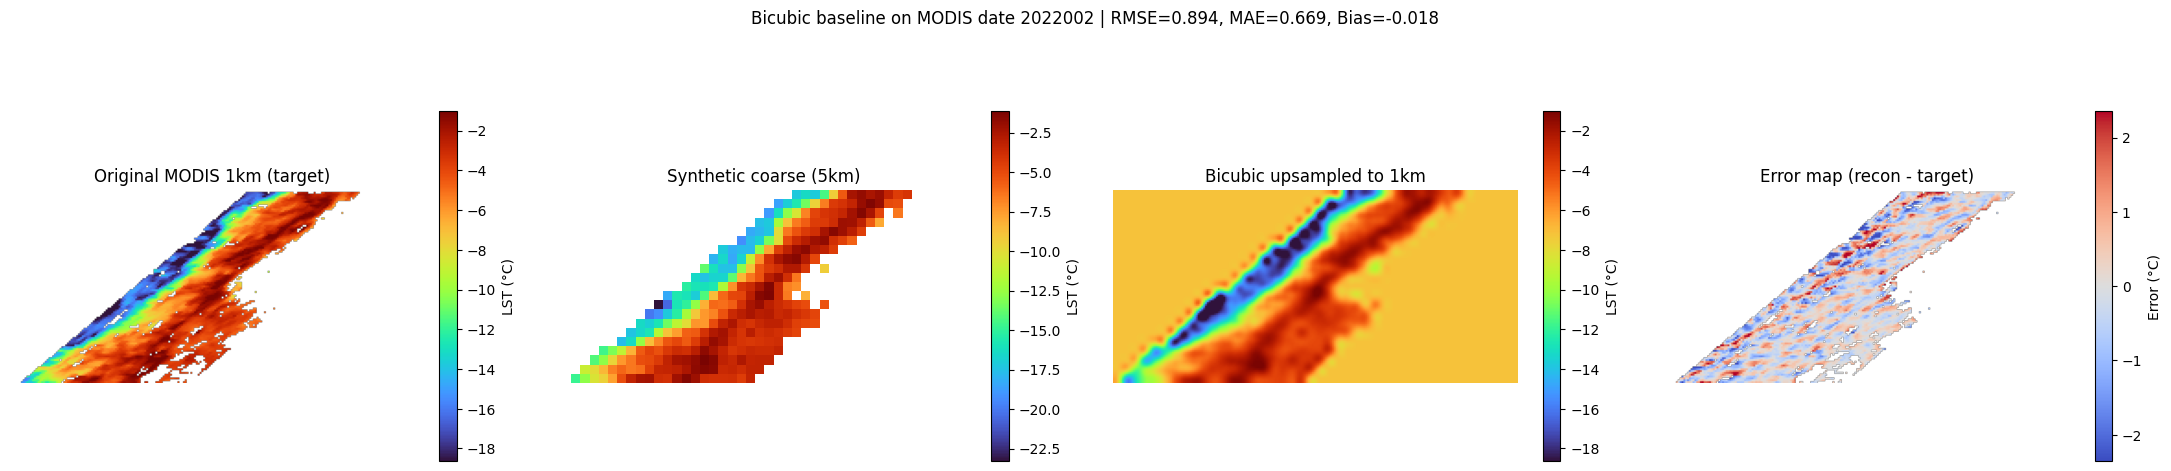

False


In [28]:
if result is not None:
    target = result['target']
    coarse = result['coarse']
    recon = result['recon']
    err = recon - target
    err[~result['eval_mask']] = np.nan

    vmin = np.nanpercentile(target, 2)
    vmax = np.nanpercentile(target, 98)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    im0 = axes[0].imshow(target, cmap='turbo', vmin=vmin, vmax=vmax)
    axes[0].set_title('Original MODIS 1km (target)')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], shrink=0.8, label='LST (°C)')

    im1 = axes[1].imshow(coarse, cmap='turbo')
    axes[1].set_title('Synthetic coarse (5km)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label='LST (°C)')

    im2 = axes[2].imshow(recon, cmap='turbo', vmin=vmin, vmax=vmax)
    axes[2].set_title('Bicubic upsampled to 1km')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], shrink=0.8, label='LST (°C)')

    err_lim = np.nanpercentile(np.abs(err), 98)
    im3 = axes[3].imshow(err, cmap='coolwarm', vmin=-err_lim, vmax=err_lim)
    axes[3].set_title('Error map (recon - target)')
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], shrink=0.8, label='Error (°C)')

    plt.suptitle(
        f'Bicubic baseline on MODIS date {sample_date} | '
        f'RMSE={result["rmse"]:.3f}, MAE={result["mae"]:.3f}, Bias={result["bias"]:.3f}',
        y=1.02
    )
    plt.tight_layout()
    plt.show()

print(result is None)

In [29]:
# Evaluate across all available dates
rows = []

for i, date_str in enumerate(all_date_strs):
    try:
        clipped_lst, clipped_transform, clipped_crs = mosaic_and_clip_modis_for_date(
            date_str,
            modis_index,
            study_area,
            use_qc=True
        )

        result = run_bicubic_on_scene(clipped_lst, factor=5, min_valid_fraction=0.20)

        if result is None:
            rows.append({
                'date_str': date_str,
                'rmse': np.nan,
                'mae': np.nan,
                'bias': np.nan,
                'valid_fraction': np.sum(np.isfinite(clipped_lst)) / clipped_lst.size,
                'status': 'skipped'
            })
        else:
            rows.append({
                'date_str': date_str,
                'rmse': result['rmse'],
                'mae': result['mae'],
                'bias': result['bias'],
                'valid_fraction': result['valid_fraction'],
                'status': 'ok'
            })

        if (i + 1) % 10 == 0:
            print(f'Processed {i + 1}/{len(all_date_strs)} dates')

    except Exception as e:
        rows.append({
            'date_str': date_str,
            'rmse': np.nan,
            'mae': np.nan,
            'bias': np.nan,
            'valid_fraction': np.nan,
            'status': f'error: {str(e)}'
        })
        print(f'Error on {date_str}: {e}')

baseline_df = pd.DataFrame(rows)
baseline_df['date'] = pd.to_datetime(
    baseline_df['date_str'].str[:4] + baseline_df['date_str'].str[4:],
    format='%Y%j',
    errors='coerce'
)

print('\nFinished baseline evaluation.')
print(baseline_df.head())

ok_df = baseline_df[baseline_df['status'] == 'ok'].copy()

print('\nSummary over valid scenes:')
print(f'Num scenes evaluated: {len(ok_df)}')
print(f'Mean RMSE: {ok_df["rmse"].mean():.3f} °C')
print(f'Mean MAE:  {ok_df["mae"].mean():.3f} °C')
print(f'Mean Bias: {ok_df["bias"].mean():.3f} °C')

Processed 10/21 dates
Processed 20/21 dates

Finished baseline evaluation.
  date_str      rmse       mae      bias  valid_fraction   status       date
0  2022001       NaN       NaN       NaN        0.036282  skipped 2022-01-01
1  2022002  0.894143  0.668872 -0.018197        0.291876       ok 2022-01-02
2  2022003       NaN       NaN       NaN        0.100793  skipped 2022-01-03
3  2022004       NaN       NaN       NaN        0.043256  skipped 2022-01-04
4  2022005       NaN       NaN       NaN        0.026734  skipped 2022-01-05

Summary over valid scenes:
Num scenes evaluated: 4
Mean RMSE: 0.941 °C
Mean MAE:  0.694 °C
Mean Bias: -0.016 °C


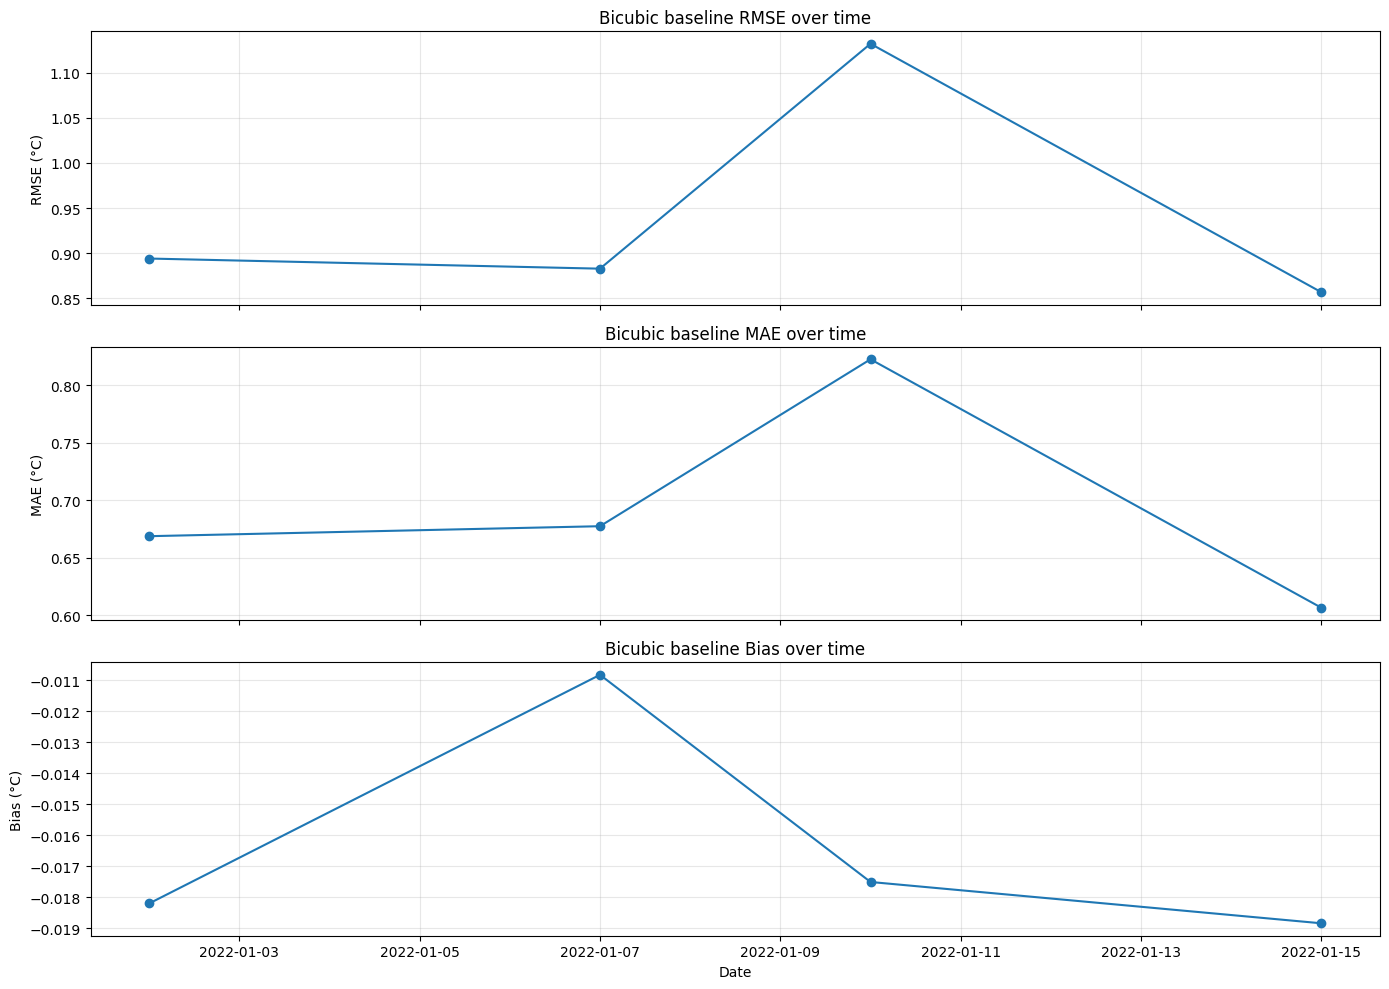

In [23]:
if len(ok_df) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(ok_df['date'], ok_df['rmse'], marker='o')
    axes[0].set_title('Bicubic baseline RMSE over time')
    axes[0].set_ylabel('RMSE (°C)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ok_df['date'], ok_df['mae'], marker='o')
    axes[1].set_title('Bicubic baseline MAE over time')
    axes[1].set_ylabel('MAE (°C)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(ok_df['date'], ok_df['bias'], marker='o')
    axes[2].set_title('Bicubic baseline Bias over time')
    axes[2].set_ylabel('Bias (°C)')
    axes[2].set_xlabel('Date')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()